In [1]:
import os
import pickle
import operator
from itertools import accumulate

import napari
import numpy as np
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm

from utils import images, extract_kps_and_calc_transform, apply_transform, display_transform

In [2]:
load_data = False
save_path = './out/aligned_volume.pkl'
os.makedirs('./out', exist_ok=True)

## Task 1: Compute Transforms

In [3]:
def extract_kps_and_calc_transforms(images):
    pbar = tqdm(zip(images, images[1:]), total=len(images) - 1, desc="Calculating Transforms")
    return [np.eye(3)] + [extract_kps_and_calc_transform(i1, i2, logging=False)['transform'] for i1, i2 in pbar]


if not load_data:
    transforms = extract_kps_and_calc_transforms(images)

Calculating Transforms:   0%|          | 0/26 [00:00<?, ?it/s]

## Task 2: Align Images

In [4]:
def align_images(images, transforms):
    stacked_transforms = list(accumulate(transforms, operator.matmul))
    aligned_images = [apply_transform(img, t) for img, t in zip(images, stacked_transforms)]
    return stacked_transforms, aligned_images


if load_data:
    with open(save_path, 'rb') as file:
        data = pickle.load(file)
        stacked_transforms, aligned_images = data['transforms'], data['volume']
else:
    stacked_transforms, aligned_images = align_images(images, transforms)

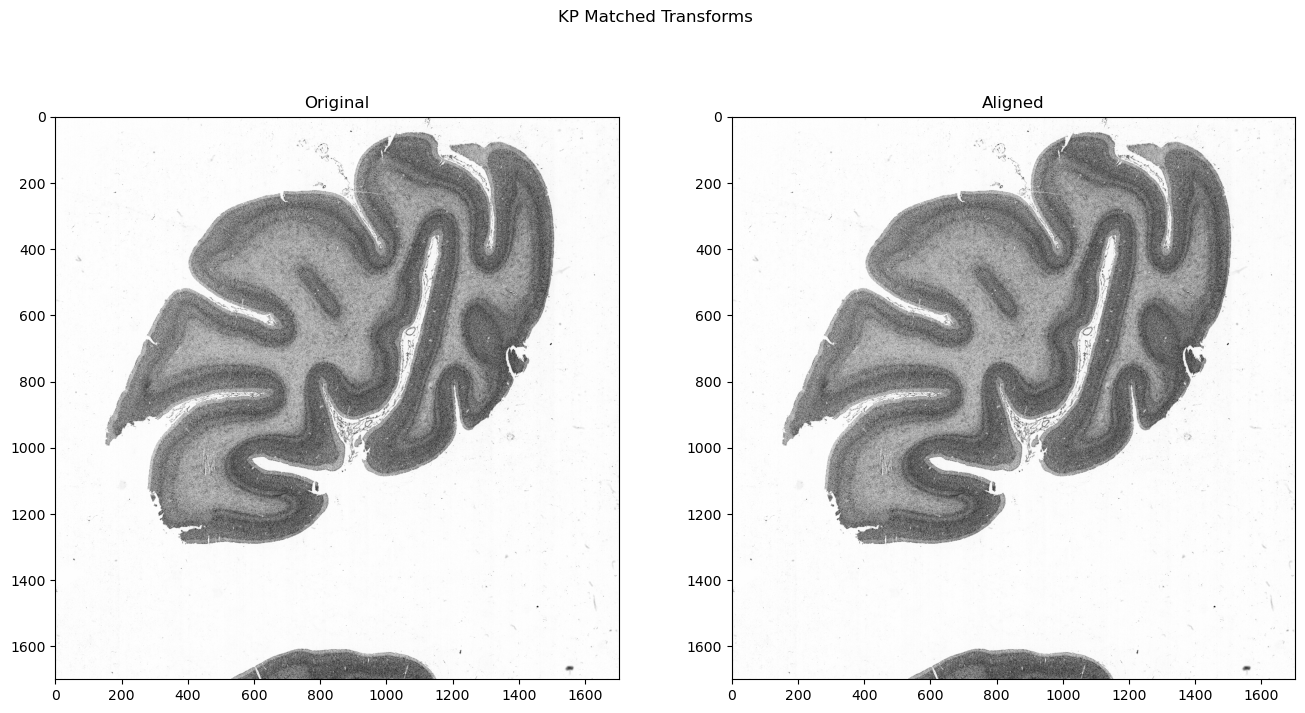

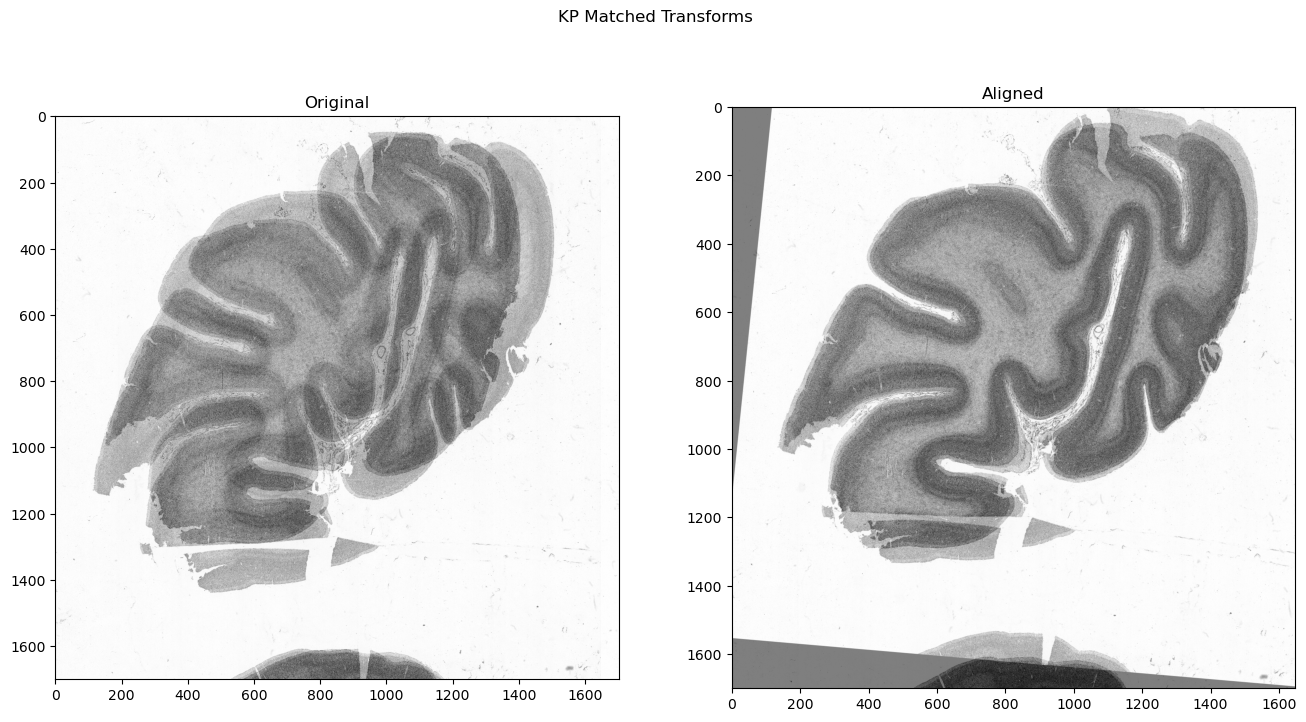

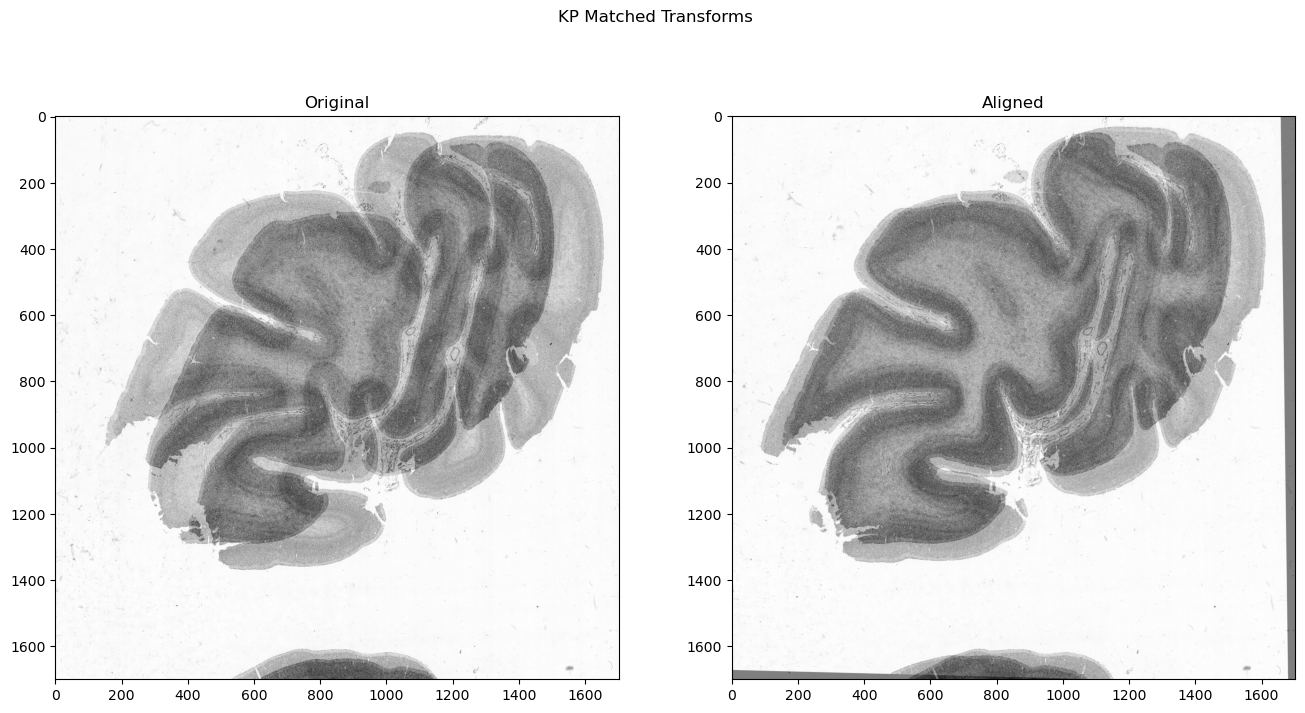

In [5]:
for dest, aligned in zip(images[::10], aligned_images[::10]):
    display_transform(images[0], dest, aligned)

## Task 3: Stack to 3D-Volume and Inspect

In [6]:
def pad_and_stack(aligned_images):
    max_val = max(i.max() for i in images)
    max_h, max_w = max(i.shape[0] for i in aligned_images), max(i.shape[1] for i in aligned_images)

    return np.stack([np.pad(img, ((0, max_h - img.shape[0]), (0, max_w - img.shape[1])), constant_values=max_val) for img in aligned_images])

In [7]:
def remove_alignment_artifacts(volume, threshold=0.95):
    volume = volume.copy()
    volume[volume > threshold] = 0
    volume /= volume.max()
    return volume

In [8]:
def view_volume(volume, colormap='bop purple'):
    napari.view_image(volume, colormap=colormap, rendering='mip', ndisplay=3, scale=(5, 1, 1))
    napari.run()

In [9]:
if load_data:
    volume = data['volume']
else:
    volume = pad_and_stack(aligned_images)
    volume = remove_alignment_artifacts(volume)
view_volume(volume)

In [10]:
if not load_data:
    with open(save_path, 'wb') as file:
        pickle.dump({
            'transforms': stacked_transforms,
            'aligned_images': aligned_images,
            'volume': volume
        }, file)

## Bonus: Trying out Filters

In [11]:
def pipeline(images, save_path):
    if load_data:
        with open(save_path, 'rb') as file:
            data = pickle.load(file)
            volume = data['volume']
    else:
        transforms = extract_kps_and_calc_transforms(images)
        stacked_transforms, aligned_images = align_images(images, transforms)
        volume = pad_and_stack(aligned_images)
        volume = remove_alignment_artifacts(volume)

        with open(save_path, 'wb') as file:
            pickle.dump({
                'transforms': stacked_transforms,
                'aligned_images': aligned_images,
                'volume': volume
            }, file)

    view_volume(volume)

In [12]:
filtered_images = [gaussian_filter(i, sigma=10) for i in images]
pipeline(filtered_images, save_path='./out/gaussian10_aligned_volume.pkl')

Calculating Transforms:   0%|          | 0/26 [00:00<?, ?it/s]